<a href="https://colab.research.google.com/github/ngocanh232911/CS4410_Extra_Credit/blob/main/Extra_credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
from io import BytesIO
import requests
import matplotlib.pyplot as plt

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [7]:
model = models.resnet18(pretrained=True)
model = model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [9]:
labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = requests.get(labels_url).text.split("\n")

In [10]:
def predict_image(url):

    headers = {"User-Agent":"Mozilla/5.0"}
    response = requests.get(url, headers=headers)

    img = Image.open(BytesIO(response.content)).convert("RGB")

    input_tensor = transform(img)
    input_batch = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_batch)

    probabilities = torch.nn.functional.softmax(output[0], dim=0)

    top5_prob, top5_catid = torch.topk(probabilities, 5)

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    print("Top 5 Predictions:\n")

    for i in range(top5_prob.size(0)):
        print(f"{labels[top5_catid[i]]}: {top5_prob[i].item()*100:.2f}%")

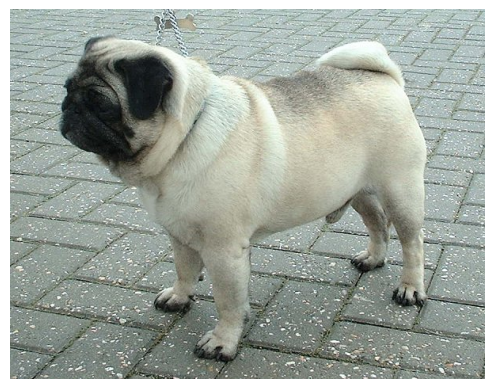

Top 5 Predictions:

pug: 99.63%
bull mastiff: 0.11%
Norwegian elkhound: 0.09%
French bulldog: 0.07%
Brabancon griffon: 0.04%


In [11]:
img1 = "https://upload.wikimedia.org/wikipedia/commons/9/9a/Pug_600.jpg"
predict_image(img1)

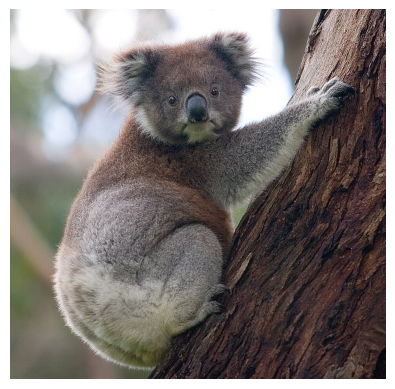

Top 5 Predictions:

koala: 99.51%
indri: 0.30%
Madagascar cat: 0.14%
fox squirrel: 0.03%
wallaby: 0.01%


In [12]:
img2 = "https://upload.wikimedia.org/wikipedia/commons/thumb/4/49/Koala_climbing_tree.jpg/960px-Koala_climbing_tree.jpg"
predict_image(img2)

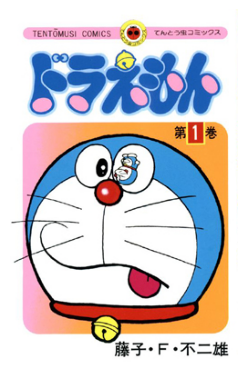

Top 5 Predictions:

comic book: 48.51%
joystick: 10.15%
envelope: 5.81%
wall clock: 3.34%
analog clock: 3.08%


In [13]:
img3 = "https://upload.wikimedia.org/wikipedia/en/c/c8/Doraemon_volume_1_cover.jpg"
predict_image(img3)